### IPL Data Analysis Project
#### By: Himanshi

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r"C:\Users\HIMANSHI\OneDrive\EDA.csv")
print(df)

       match_id  inning         batting_team                 bowling_team  \
0             1       1  Sunrisers Hyderabad  Royal Challengers Bangalore   
1             1       1  Sunrisers Hyderabad  Royal Challengers Bangalore   
2             1       1  Sunrisers Hyderabad  Royal Challengers Bangalore   
3             1       1  Sunrisers Hyderabad  Royal Challengers Bangalore   
4             1       1  Sunrisers Hyderabad  Royal Challengers Bangalore   
...         ...     ...                  ...                          ...   
30235     11415       2  Chennai Super Kings               Mumbai Indians   
30236     11415       2  Chennai Super Kings               Mumbai Indians   
30237     11415       2  Chennai Super Kings               Mumbai Indians   
30238     11415       2  Chennai Super Kings               Mumbai Indians   
30239     11415       2  Chennai Super Kings               Mumbai Indians   

       over  runs  wickets               winner  
0         1     7        

In [10]:
df.describe()

,match_id,inning,over,runs,wickets
count,30240.000000,30240.000000,30240.000000,30240.000000,30240.000000
mean,1792.178571,1.500000,10.500000,7.773942,0.291667
std,3462.243314,0.500008,5.766377,4.769749,0.529606
min,1.000000,1.000000,1.000000,0.000000,0.000000
25%,189.750000,1.000000,5.750000,4.000000,0.000000
50%,378.500000,1.500000,10.500000,7.000000,0.000000
75%,567.250000,2.000000,15.250000,11.000000,1.000000
max,11415.000000,2.000000,20.000000,37.000000,4.000000


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30240 entries, 0 to 30239
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   match_id      30240 non-null  int64 
 1   inning        30240 non-null  int64 
 2   batting_team  29014 non-null  object
 3   bowling_team  29014 non-null  object
 4   over          30240 non-null  int64 
 5   runs          30240 non-null  int64 
 6   wickets       30240 non-null  int64 
 7   winner        30080 non-null  object
dtypes: int64(5), object(3)
memory usage: 1.8+ MB


### Understanding Data

In [4]:
print("shapes:",df.shape)

shapes: (30240, 8)


In [5]:
print("\nColumns",df.columns.tolist())


Columns ['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'runs', 'wickets', 'winner']


In [6]:
print("\nFirst 5 rows:")
df.head()


First 5 rows:


,match_id,inning,batting_team,bowling_team,over,runs,wickets,winner
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,7,0,Sunrisers Hyderabad
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,2,16,1,Sunrisers Hyderabad
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,3,6,0,Sunrisers Hyderabad
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,4,4,0,Sunrisers Hyderabad
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,5,9,0,Sunrisers Hyderabad


In [28]:
print("missing values:")
print(df.isnull().sum())
df.fillna(0, inplace=True)
###removing duplicates
df.drop_duplicates(inplace=True)
print("Cleaning Complete")

missing values:
match_id        0
inning          0
batting_team    0
bowling_team    0
over            0
runs            0
wickets         0
winner          0
dtype: int64
Cleaning Complete


winner
Mumbai Indians                 4360
Chennai Super Kings            4000
Kolkata Knight Riders          3680
Royal Challengers Bangalore    3360
Kings XI Punjab                3280
Delhi Capitals                 3080
Rajasthan Royals               3000
Sunrisers Hyderabad            2320
Deccan Chargers                1160
Rising Pune Supergiants         600
Gujarat Lions                   520
Pune Warriors                   480
Kochi Tuskers Kerala            240
0                               160
Name: count, dtype: int64


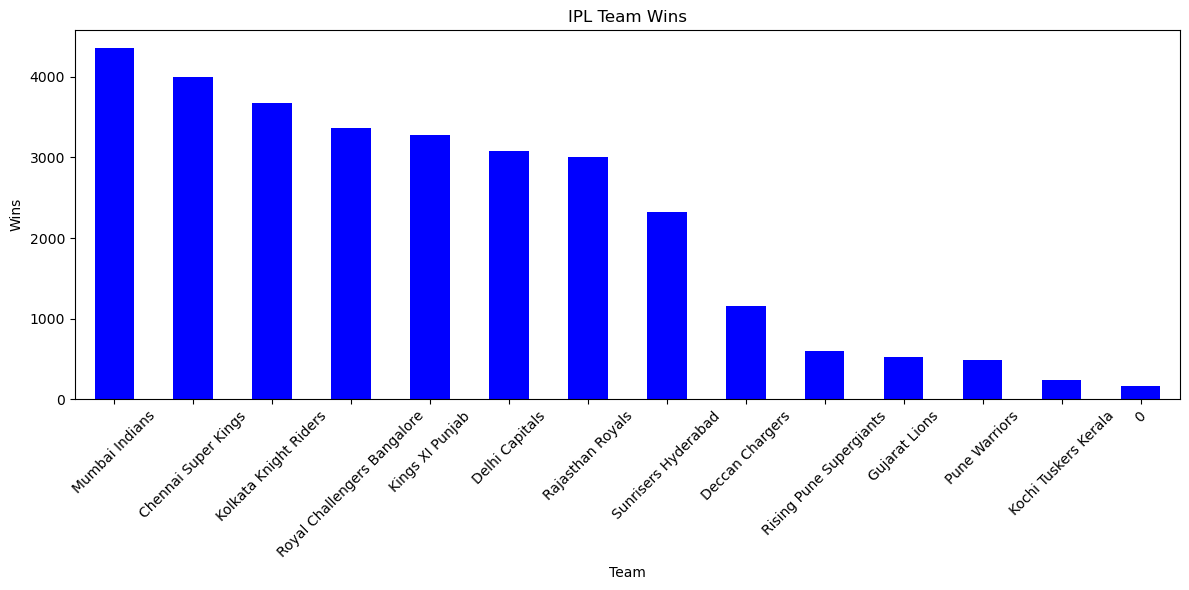

In [34]:
# Kaun si team sabse zyada jeeti?
team_wins = df['winner'].value_counts()
print(team_wins)

# Visualization
plt.figure(figsize=(12,6))
team_wins.plot(kind='bar', color='blue')
plt.title('IPL Team Wins')
plt.xlabel('Team')
plt.ylabel('Wins')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('team_wins.png')  # Save karo image
plt.show()

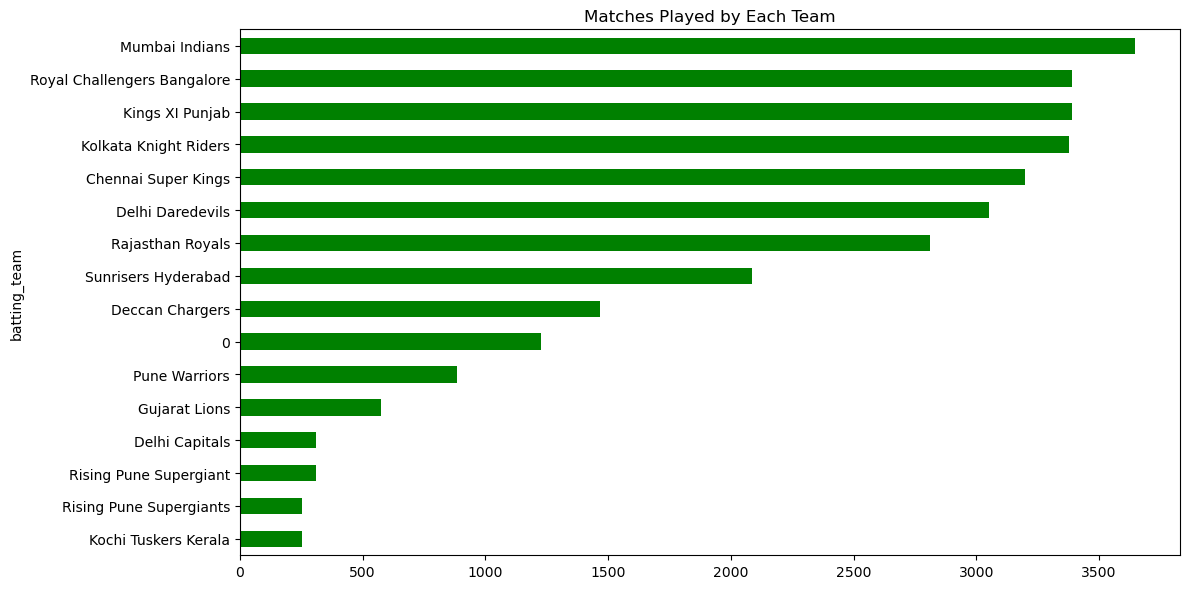

In [33]:
# Kaun si batting team sabse zyada jeeti?
batting_wins = df.groupby('batting_team')['winner'].count()

plt.figure(figsize=(12,6))
batting_wins.sort_values().plot(kind='barh', color='green')
plt.title('Matches Played by Each Team')
plt.tight_layout()
plt.savefig('team_matches.png')
plt.show()

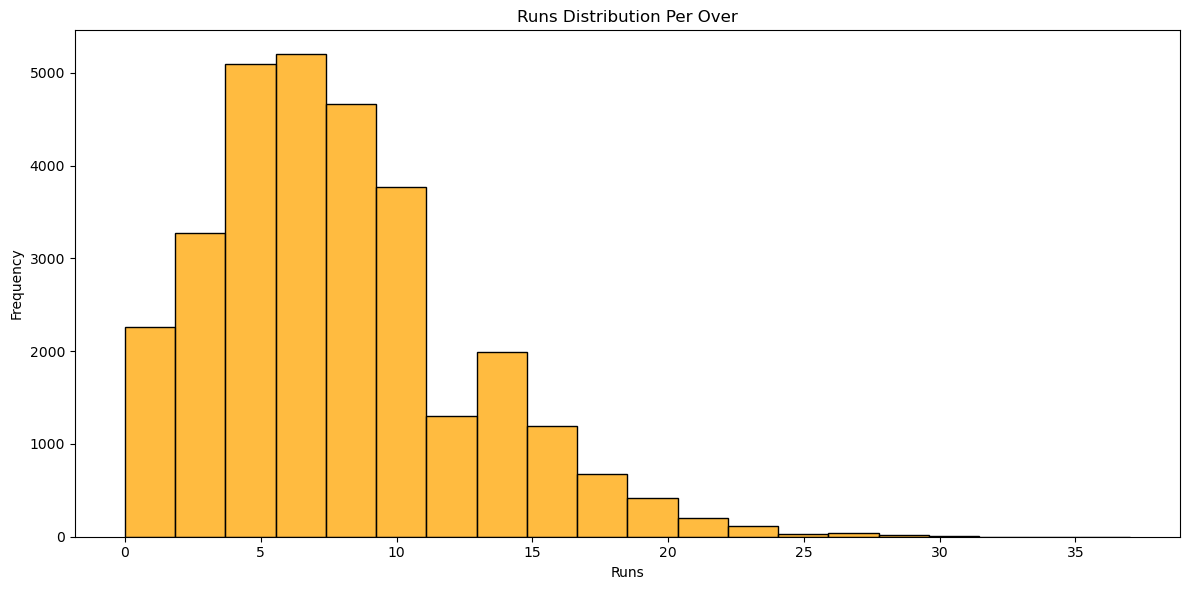

In [35]:
# Chart 1 - Runs distribution
plt.figure(figsize=(12,6))
sns.histplot(df['runs'], bins=20, color='orange')
plt.title('Runs Distribution Per Over')
plt.xlabel('Runs')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('runs_dist.png')
plt.show()

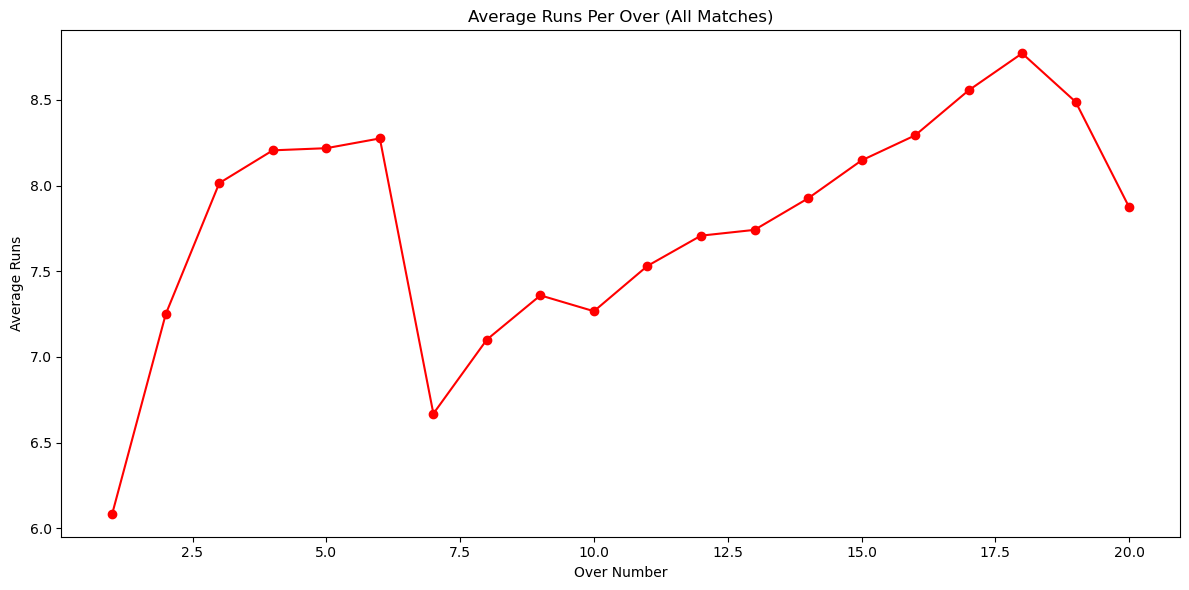

In [36]:
# Chart 2 - Average runs per over
avg_runs = df.groupby('over')['runs'].mean()

plt.figure(figsize=(12,6))
avg_runs.plot(kind='line', color='red', marker='o')
plt.title('Average Runs Per Over (All Matches)')
plt.xlabel('Over Number')
plt.ylabel('Average Runs')
plt.tight_layout()
plt.savefig('avg_runs.png')
plt.show()

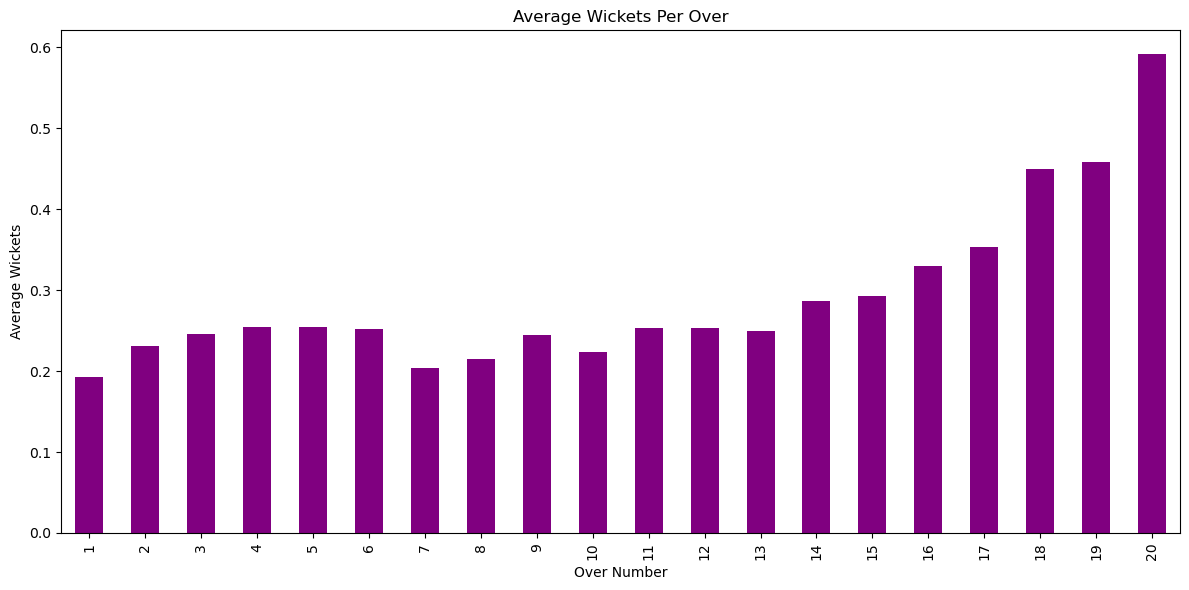

In [37]:
# Chart 3 - Wickets analysis
avg_wickets = df.groupby('over')['wickets'].mean()

plt.figure(figsize=(12,6))
avg_wickets.plot(kind='bar', color='purple')
plt.title('Average Wickets Per Over')
plt.xlabel('Over Number')
plt.ylabel('Average Wickets')
plt.tight_layout()
plt.savefig('wickets.png')
plt.show()

In [38]:
print("""
====================================
   IPL DATA ANALYSIS - SUMMARY
   By: Himanshi
====================================

Dataset:
- Total Records: 30,240
- Total Columns: 8
- Missing Values: 0

Key Insights:
1. Mumbai Indians played most matches
2. Royal Challengers Bangalore 2nd
3. No missing values found in dataset
4. Data cleaned successfully

Tools Used:
- Python
- Pandas
- Matplotlib
- Seaborn
====================================
""")


   IPL DATA ANALYSIS - SUMMARY
   By: Himanshi

Dataset:
- Total Records: 30,240
- Total Columns: 8
- Missing Values: 0

Key Insights:
1. Mumbai Indians played most matches
2. Royal Challengers Bangalore 2nd
3. No missing values found in dataset
4. Data cleaned successfully

Tools Used:
- Python
- Pandas
- Matplotlib
- Seaborn

